# **Problem Statement**

## Business Context

Legal aid providers assisting tenants with rental disputes face increasing operational pressure. They must interpret statutory guidance, review lease clauses, and reference prior judgments while responding to a high volume of tenant inquiries.

Currently, this process is largely manual:

- Staff consult internal PDFs and prior case records.

- Clarifications must be requested repeatedly (e.g., notice period, tenancy duration, jurisdiction).

- Responses vary depending on staff experience and time constraints.

- Delays increase the risk of missed deadlines and procedural errors.

Unlike general internet searches, tenant-landlord disputes require structured reasoning, controlled document grounding, and escalation safeguards. A simple search engine cannot reliably enforce document boundaries, validate statutory relevance, or abstain when legal support is insufficient.

Therefore, an agent-based system is required to coordinate parsing, retrieval, validation, and response generation within a controlled workflow.

## Dataset

The following data files are provided and will be used by the AI agent-based system as source documents.

- `tenants_rights.pdf`: The document is a guide that explains residential tenants' rights and protections, covering topics such as types of housing, leases, rent, eviction, habitability, safety, utility services, and personal protections against discrimination and harassment
- `previous_judgements.pdf`: The document is an archive of past rental law case records detailing the parties, legal issues, statutes cited, verdicts, and court holdings on topics like security deposits, eviction, rent increases, habitability, and succession rights.

# **Installing and Importing Necessary Libraries**

In [ ]:
!pip install openai==1.66.3 \
            langchain==0.3.20 \
            langchain-openai==0.3.9 \
            langchain_experimental==0.3.4 \
            pypdf==5.4.0 \
            langgraph==0.3.21 \
            chromadb==1.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# ===============================
# Core Python
# ===============================
import os
import json
from typing import TypedDict, List, Set

# ===============================
# LangChain Core
# ===============================
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage,
    BaseMessage
)
from langchain_core.tools import tool

# ===============================
# LangChain OpenAI
# ===============================
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# ===============================
# Vector Store + Document Processing
# ===============================
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma

# ===============================
# LangGraph
# ===============================
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages

# ===============================
# LangSmith (Tracing)
# ===============================
from langsmith import traceable, Client

# **LLM and Agent Observability Setup**

#### LangSmith Setup

In a multi-agent system, multiple agents and tools may run in sequence, passing state and intermediate results between them. As the workflow grows in complexity, it becomes challenging to understand:

- why a particular routing decision was made,
- which documents or chunks were retrieved,
- where an incorrect or unexpected output originated,

and more.

LangSmith provides observability for agentic AI workflows by logging:

- the end-to-end execution flow
- all tool and agent calls
- intermediate inputs and outputs
- key performance metrics

With LangSmith, one can debug errors, evaluate system behavior, and validate that a workflow is executing as intended. Without this level of tracing, diagnosing issues in complex agentic AI workflows becomes time-consuming and error-prone.

**How to obtain a LangSmith API Key?**

1. Visit: [https://smith.langchain.com](https://smith.langchain.com)  
2. Sign in and go to **Settings → API Keys**  
3. Generate a new API key  
4. Store this key securely (for example, in a `config.json` file or environment variables)

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name"
}
```

**Note**: The API key enables tracing for the specific project workspace.

#### OpenAI API Setup

The credentials for OpenAI setup need to be stored in the same `config.json` file as the LangSmith credentials.

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name",
  "OPENAI_API_KEY": "your_openai_key",
  "OPENAI_API_BASE": "your_openai_base_url"
}

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

For the problem at hand, we will use two LLMs to separate responsibilities
- a lightweight model for primary reasoning and generation, and
- a more complex model for evaluation and validation, ensuring better accuracy, reliability, and cost efficiency.


In [ ]:
# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Initialize separate LLM for validation (more complex model)
eval_llm = ChatOpenAI(model="gpt-4o", temperature=0)

# **Multi-Agent System Architecture**

We will design a structured multi-agent system for a tenant-landlord legal reasoning system. The objective is to ensure domain control, grounded document retrieval, and modular reasoning.

The system is composed of three coordinated agents, each with a distinct responsibility.

<font size=4>**1. Orchestration Agent**</font>

This agent manages the overall workflow of the system upon receiving a user query.

- Routes the query and intermediate results between the other agents
- Enforces the correct execution order
- Applies stopping conditions (e.g., stops processing when the query is found to be out of scope or when a satisfactory answer has been produced)

<font size=4>**2. Parse Agent**</font>

This agent is responsible for understanding and validating the user's input:

- Checks whether the query falls within the scope of tenant-landlord (rental) law
- Identifies the legal intent behind the query (e.g., eviction, rent increase, security deposit)
- Converts the raw query into a structured representation that downstream agents can use

<font size=4>**3. Response Agent**</font>

This agent performs retrieval and grounded answer generation:

- Uses the structured representation from the Parse Agent to query the rental-law knowledge base
- Retrieves the most relevant document sections (chunks) related to the user's issue
- Validates these chunks to ensure they are on-topic and jurisdictionally correct
- Generates a final legal response that is:
  - Grounded in the retrieved documents
  - Explicit about any uncertainties or gaps in the available information

## Agent State

**`UnifiedState`** defines the shared state schema that carries query data, intermediate agent outputs, retrieval metadata, routing decisions, and the final response across all agents in the multi-agent workflow.


In [ ]:
class UnifiedState(TypedDict):
    # Original user query text
    user_query: str

    # Full message history (user, system, and agent messages)
    messages: List[BaseMessage]

    # -------------------------
    # Parse Agent state fields
    # -------------------------

    # Initial parsed representation of the query
    parsed_output: str

    # Refined / post-processed version of the parsed output
    refined_output: str

    # Routing decision from the Parse Agent
    # (e.g., "in_scope", "out_of_scope", "needs_clarification")
    parse_route: str

    # -------------------------
    # Legal RAG Agent state fields
    # -------------------------

    # Retrieved case-law-related chunks
    case_chunks: str

    # Retrieved statutory / regulatory / guidance chunks
    legal_chunks: str

    # Validation result of the retrieved chunks
    # (e.g., "valid", "insufficient", "conflicting")
    validation_status: str

    # Number of retrieval attempts performed so far
    retrieval_attempt: int

    # IDs of legal documents/chunks already seen
    # to prevent duplicate retrieval
    seen_legal_ids: Set[str]

    # -------------------------
    # Orchestration state field
    # -------------------------

    # Identifier of the next agent to execute
    # (e.g., "parse_agent", "rag_agent", "terminate")
    next_agent: str

    # -------------------------
    # Final response field
    # -------------------------

    # Final answer returned to the user
    final_output: str

## Agent 1: Orchestration Agent

Here, we use a **deterministic, rule-based orchestration agent** to control the flow between the Parse Agent and the Legal RAG Agent.

The routing logic is predefined.

1. **Parsing first:** If the query has not yet been parsed, it routes the state to the parsing agent.
2. **Scope check next:** Once parsing is done, it checks whether the query has been classified as out of scope; if so, it finalizes the response and stops the workflow.
3. **Legal reasoning step:** If the query is in scope and marked for legal reasoning, and no final answer exists yet, it routes the state to the legal RAG agent.
4. **Fallback stop:** If none of these conditions apply, it stops the workflow without invoking any additional agents.

In [ ]:
def orchestrator_node(state: UnifiedState):
    """
    Central routing controller.
    Decides which agent runs next.
    """

    # First entry → run parse agent
    if not state.get("parsed_output"):
        state["next_agent"] = "parse_agent"
        return state

    # After parsing → check scope
    if "OUT_OF_SCOPE" in state.get("refined_output", ""):
        state["final_output"] = state["refined_output"]
        state["next_agent"] = "END"
        return state

    # If parsing successful and RAG not yet executed
    if state.get("parse_route") == "response_agent" and not state.get("final_output"):
      state["next_agent"] = "response_agent"
      return state

    # Otherwise stop
    state["next_agent"] = "END"

    return state

## Agent 2: Parse Agent

The Parse Agent uses two tools:

* **`parse_query`** - A rule-based tool that applies `if-else` logic to validate tenant-landlord scope and structure the query.
* **`validate_and_refine_parsed_query`** - An LLM-based validation tool that reviews and refines the parsed output without adding legal advice.

This ensures controlled scope validation followed by structured refinement before passing the query to downstream agents.

#### Tool: Parse Query

This tool checks whether a query is about tenant-landlord issues and, if so, extracts a lightweight structure:
- high-level intent,
- basic housing context (property/tenancy type), and
- key legal issue tags

, returning them as a readable summary for downstream agents.

In [ ]:
@tool
def parse_query(query: str) -> str:
    """
    Parse and validate a tenant legal query.
    Rejects non-tenant law queries.
    """

    q = query.lower()

    # Domain guardrail
    tenant_keywords = [
        # Parties & roles
        "tenant", "renter", "landlord", "property owner",
        "property manager", "housing authority",

        # Tenancy & lease structure
        "lease", "rental agreement", "tenancy agreement",
        "fixed term", "month-to-month", "renewal",
        "early termination", "sublease",

        # Rent, fees & money
        "rent", "rent payment", "rent increase", "rent stabilized",
        "nonpayment", "late fee", "application fee",
        "broker fee", "pet fee",

        # Eviction, notices & court
        "eviction", "notice to quit", "notice of termination",
        "pay or quit", "housing court", "court summons",
        "notice period", "written notice", "30 day notice",

        # Security deposit & move-out condition
        "security deposit", "deposit refund", "deposit deductions",
        "normal wear and tear", "move out", "move in",
        "move-out inspection", "vacate",

        # Repairs, safety & habitability
        "repair", "maintenance", "habitability",
        "unsafe conditions", "code violation", "housing code",
        "mold", "leak", "infestation", "pest",
        "plumbing", "electricity", "gas", "smoke detector",

        # Access, privacy & retaliation
        "right of entry", "entry notice", "privacy",
        "harassment", "retaliation", "lockout",
        "illegal lockout", "utility shutoff",

        # Discrimination & accommodations
        "discrimination", "fair housing",
        "reasonable accommodation", "disability accommodation",
        "service animal", "emotional support animal",
        "source of income discrimination",

        # Property & use restrictions
        "apartment", "unit", "house", "condo",
        "room rental", "occupancy limit",
        "certificate of occupancy", "illegal apartment",
        "short term rental", "airbnb",

        # Utilities & services
        "utilities", "electric bill", "water bill", "gas bill"
    ]

    if not any(k in q for k in tenant_keywords):
        return (
            "OUT_OF_SCOPE:\n"
            "This agent handles tenant-landlord (rental) law only.\n"
            "Please ask an in-scope question."
        )

    # --- Intent detection ---
    if "evict" in q or "eviction" in q:
        intent = "Eviction Defense / Eviction Process"
    elif "rent increase" in q or "raise rent" in q:
        intent = "Rent Control / Rent Increase Legality"
    elif "security deposit" in q:
        intent = "Security Deposit Dispute"
    elif "repair" in q or "habitability" in q:
        intent = "Repairs & Habitability Rights"
    elif "lease" in q:
        intent = "Lease Review / Interpretation"
    elif "retaliation" in q:
        intent = "Tenant Retaliation Claim"
    elif "discrimination" in q:
        intent = "Housing Discrimination"
    else:
        intent = "General Tenant Rights Inquiry"


    # --- Housing context ---
    property_type = "Unspecified Residential Unit"
    if "apartment" in q:
        property_type = "Apartment"
    elif "house" in q:
        property_type = "Single-family Home"
    elif "condo" in q:
        property_type = "Condominium"

    tenancy_type = "Unspecified"
    if "month-to-month" in q:
        tenancy_type = "Month-to-Month"
    elif "fixed term" in q or "1 year" in q:
        tenancy_type = "Fixed-Term Lease"

    # --- Legal issues ---
    legal_issues = []

    if "notice" in q:
        legal_issues.append("Notice requirements")
    if "deposit" in q:
        legal_issues.append("Security deposit handling")
    if "repair" in q:
        legal_issues.append("Implied warranty of habitability")
    if "lockout" in q:
        legal_issues.append("Illegal lockout")
    if "rent" in q:
        legal_issues.append("Rent payment obligations")

    if not legal_issues:
        legal_issues.append("General tenant protections")


    # --- Output ---
    return f"""
Parsed Tenant Law Query
-----------------------

Scope Validation:
- Tenant / Landlord Law: CONFIRMED

User Intent:
- {intent}

Property Type:
- {property_type}

Tenancy Type:
- {tenancy_type}

Key Legal Issues:
- """ + "\n- ".join(legal_issues) + f"""
"""

#### Tool: Validate and Refine Parsed Query

This tool adds an LLM-based validation layer on top of the initial parsing step. It checks that the query is truly about residential tenant-landlord law, is legally actionable, and that the parsed structure is correctly formatted.

It either returns a strict `OUT_OF_SCOPE` line or a minimally cleaned version of the structured output, without adding any new analysis or advice.

In [ ]:
@tool
def validate_and_refine_parsed_query(query: str, parsed_output: str) -> str:
    """
    LLM validation layer for parsed tenant-law query.
    Acts as a strict scope and formatting gate.
    """

    refine_query_prompt = f"""
You are a strict validation layer in a legal AI system.

Your role is ONLY to validate and minimally refine structured tenant-landlord parsing output.

----------------------------------------
ORIGINAL USER QUERY:
{query}

INITIAL PARSED OUTPUT:
{parsed_output}
----------------------------------------

VALIDATION RULES:

1. Scope Check:
   - If the original query is NOT about residential tenant-landlord law,
     return EXACTLY:
     OUT_OF_SCOPE: This agent handles tenant-landlord (rental) law only. Please ask an in-scope question.

2. Legal Question Check:
   - If the query is vague, incomplete, hypothetical without context,
     or not legally actionable,
     return EXACTLY:
     OUT_OF_SCOPE: The question is unclear or not legally actionable. Please rephrase the question.

3. Parser Error Correction:
   - If the initial parser incorrectly rejected a valid tenant query,
     correct the structured output.
   - Do NOT invent facts.
   - Only fix classification or formatting mistakes.

4. If VALID:
   - Keep original structure.
   - Clean formatting only.
   - Do NOT add legal advice.
   - Do NOT expand analysis.
   - Do NOT introduce new sections.
   - Do NOT change meaning.

5. Output Rules:
   - Return ONLY one of the following:
        a) The corrected structured output.
        OR
        b) The OUT_OF_SCOPE message
   - No explanations, commentary, or additional text.

This is a validation layer, not a legal advisor.
"""

    response = eval_llm.invoke(refine_query_prompt)
    return response.content.strip()

#### Agent Execution Logic

This node implements the Parse Agent's execution logic by first applying rule-based query parsing and then performing LLM-driven validation. The validated output is saved in the shared state and forwarded to the Legal RAG Agent for further reasoning.


> **Note:** The `@traceable` decorator enables LangSmith tracing, allowing us to analyze, monitor, and debug the execution of the `parse_agent_node`, including inputs, outputs, and intermediate steps.

In [ ]:
@traceable(name="parse_agent_node")
def parse_agent_node(state: UnifiedState):
    user_query = state["user_query"]  # Read the raw user query from shared state

    # Step 1: Keyword-based parsing (fast, deterministic structuring + scope screen)
    parsed_output = parse_query.invoke({
        "query": user_query
    })
    state["parsed_output"] = parsed_output  # Persist intermediate result for downstream agents/logging

    # Step 2: LLM validation/refinement layer
    # Produces either a strict OUT_OF_SCOPE line or minimally cleaned/corrected structured output.
    refined_output = validate_and_refine_parsed_query.invoke({
        "query": user_query,
        "parsed_output": parsed_output
    })
    state["refined_output"] = refined_output  # Persist refined version for routing/answering

    # Route decision for the orchestrator (here: always proceed to legal reasoning agent)
    state["parse_route"] = "response_agent"

    return state  # Return updated shared state to the workflow engine

## Agent 3: Response Agent

The Response Agent uses multiple structured tools:

* **`policy_search_tool`** - Retrieves relevant document chunks from the knowledge base using similarity search with controlled expansion.
* **`cases_search_tool`** - Retrieves at most one supporting case for contextual reinforcement.
* **`validate_chunks_tool`** - Validates whether the retrieved content is relevant to the query before proceeding.
* **`reply_tool`** - Generates the final grounded legal response strictly based on the retrieved content.

This ensures controlled retrieval, relevance validation, and grounded answer generation within a single structured workflow.


#### Setting up Vector Database

We first set up a vector database to enable semantic retrieval from the policy and case documents.

This function builds a persistent Chroma vector store from a PDF. It
- loads the document,
- splits it into overlapping text chunks,
- embeds each chunk, and
- stores the embeddings under a named collection for later retrieval

In [ ]:
def build_chroma(pdf_path, collection_name, n_chunk_size=1000, n_chunk_overlap=150):

    loader = PyPDFLoader(pdf_path)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=n_chunk_size,
        chunk_overlap=n_chunk_overlap
    )
    split_docs = splitter.split_documents(docs)

    embeddings = OpenAIEmbeddings()

    vectordb = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        collection_name=collection_name,
        persist_directory="./chroma_db"
    )

    return vectordb

These calls build two separate Chroma vector stores
- one from the tenant rights policy document, and
- one from prior court judgments document

, each with its own chunking configuration and collection name.

We use different chunk sizes because the two document types differ structurally.

- Policy documents contain longer, structured legal explanations, so a larger chunk size preserves contextual continuity during retrieval.
- Case records contain shorter, self-contained narratives, so a smaller chunk size helps retrieve precise case facts.

In [ ]:
# Build a vector store for tenant rights policy document
policy_vectorstore = build_chroma(
    "tenants_rights.pdf",          # path to policy PDF
    "policy_vectorstore_collection",        # Chroma collection name
    2000,                                   # chunk size
    200                                     # chunk overlap
)

# Build a vector store for prior court judgments document
cases_vectorstore = build_chroma(
    "previous_judgements.pdf",      # path to case law PDF
    "cases_vectorstore_collection",         # Chroma collection name
    1150,                                   # chunk size
    50                                      # chunk overlap
)

#### Tool: Policy Search Tool

This tool performs recursive retrieval over the tenant-rights policy vector store to retrieve relevant policy document chunks using semantic search, while avoiding duplicate retrieval through ID tracking.

We implement a **recursive retrieval** that
- progressively expands the search scope across attempts,
- deduplicates previously seen chunks, and
- returns only a bounded set of new, unseen passages for downstream validation and answering.

In [ ]:
@tool
def policy_search_tool(query: str, attempt: int, seen_ids: list) -> str:
    """
    Retrieve policy chunks using recursive retrival.
    """

    # ---------------------------------------------
    # Step 1: Dynamically expand search scope
    # ---------------------------------------------
    # Increase the number of retrieved candidates
    # with each recursive attempt.
    k = 5 * attempt

    # Perform similarity search in the policy vector store
    docs = policy_vectorstore.similarity_search(query, k=k)

    # Containers for new unseen chunks
    new_chunks = []
    new_ids = []

    # ---------------------------------------------
    # Step 2: Filter out previously retrieved chunks
    # ---------------------------------------------
    for doc in docs:
        # Create a unique document ID using source + page number
        doc_id = doc.metadata.get("source", "") + str(doc.metadata.get("page", ""))

        # Only include chunks not seen in prior attempts
        if doc_id not in seen_ids:
            new_chunks.append(doc.page_content)
            new_ids.append(doc_id)

        # Limit to maximum of 5 new chunks per retrieval step
        if len(new_chunks) == 5:
            break

    # ---------------------------------------------
    # Step 3: Handle no-new-content scenario
    # ---------------------------------------------
    if not new_chunks:
        return "NO_NEW_POLICIES"

    # ---------------------------------------------
    # Step 4: Return structured retrieval result
    # ---------------------------------------------
    return {
        "policy_chunks": "\n\n".join(new_chunks),  # Concatenate chunks
        "new_ids": new_ids                         # Track IDs to prevent duplication
    }

#### Tool: Case Search Tool

This tool retrieves relevant case document chunks using similarity search to provide supporting judicial context, and since the case dataset is limited in size, recursive re-fetching or expansion is not required.

In [ ]:
@tool
def cases_search_tool(query: str) -> dict:
    """
    Retrieve ONE supporting case from the case archive
    based on semantic similarity with the user query.
    """

    # Perform vector similarity search on the cases vector store
    # k=4 retrieves the top 4 most semantically similar case chunks
    docs = cases_vectorstore.similarity_search(query, k=4)

    # If no relevant case documents are found,
    # return an explicit status flag for the agent to handle
    if not docs:
        return {
            "chunk": "",
            "status": "NO_CASE_FOUND"
        }

    # If matching cases are found,
    # concatenate their page content into a single string
    # This allows the LLM to analyze supporting precedent
    return {
        "chunks": "\n\n".join([doc.page_content for doc in docs])
    }

#### Tool: Validate Chunks

This tool evaluates whether the retrieved document chunks are sufficiently relevant to answer the query, enabling controlled continuation or recursive expansion within the RAG workflow.


In [ ]:
@tool
def validate_chunks_tool(query: str, combined_chunks: str) -> str:
    """
    Validate ONLY statutory relevance.
    Ensures retrieved legal policy content is sufficient
    to answer the user's query before proceeding.
    """

    # Construct a structured validation prompt
    # The LLM evaluates whether retrieved statutory chunks
    # are relevant and sufficient to answer the query
    validate_chunks_prompt = f"""
Query:
{query}

Retrieved Content:
{combined_chunks}

Are these chunks sufficient and relevant
to answer the question?

Respond strictly:
RELEVANT
or
NOT_RELEVANT
"""

    # Invoke the LLM for binary validation
    response = llm.invoke(validate_chunks_prompt)

    # Return a clean, trimmed result to avoid formatting noise
    return response.content.strip()


#### Reply Tool

This tool generates the final legal answer by grounding primarily in statutory/policy text and optionally using case-law chunks as secondary support, and enforces structured output and prohibiting external knowledge or speculation.


In [ ]:
@tool
def reply_tool(query: str, policy_chunks: str, case_chunks: str) -> str:
    """
    Generate final grounded response.
    """

    response_prompt = f"""
You are a Residential Rental Law Query Answering Assistant.

Query:
{query}

Authoritative Policy Content (Primary Source of Truth):
{policy_chunks}

Supporting Case Content (Secondary Source of Truth - use only if directly relevant):
{case_chunks}

STRICT INSTRUCTIONS:

1. Base your legal answer primarily on the statutory/policy content.
2. Treat case content as supporting authority only.
3. Use case content ONLY if it directly reinforces or clarifies the statute.
4. If a case is used, reference it briefly at the END of the answer.
5. Be factual, structured, and precise.
6. Do NOT add outside knowledge or speculate.
7. Do NOT merge case reasoning into the main statutory explanation.
8. Do NOT explain your reasoning process.

Output Format:

- Provide the explanation first.
- If applicable, add at the end:

  Supporting Case Reference: (If any)
  [Case Name] - [Brief relevance summary]

Return only the final legal response.
"""

    response = llm.invoke(response_prompt)
    return response.content.strip()

#### Agent Execution Logic

We first define the set of tools available to the Response Agent and bind them to the LLM to enable structured tool-calling.

In [ ]:
response_tools = [
    policy_search_tool,
    validate_chunks_tool,
    cases_search_tool,
    reply_tool
]

# Enable tool-calling: the model can now request these tools by name.
llm_response_agent = llm.bind_tools(response_tools)

We now define the structured tool-driven prompt for the Response Agent, enforcing ordered retrieval, validation, controlled recursive expansion, and grounded response generation within strict execution constraints.


In [ ]:
RESPONSE_AGENT_PROMPT = """
You are a Policy-First Legal RAG Agent.

Your task is to answer tenant-landlord legal queries using a structured,
tool-driven workflow. You must strictly follow the sequence below.

MANDATORY WORKFLOW:

STEP 1 — Policy Retrieval
- Call policy_search_tool first.
- Retrieve statutory/policy content only.
- Store retrieved policy content.
- Do NOT call any other tool before this step.

STEP 2 — Case Retrieval
- Call cases_search_tool once.
- Do NOT attempt recursive case retrieval.
- Case content is secondary authority.

STEP 3 — Policy Validation
- Call validate_chunks_tool.

STEP 4 — Recursive Expansion (Policy Only)
- If validation result is NOT_RELEVANT:
    - Call policy_search_tool again with expanded search.
    - Append new policy content to existing policy content.
    - Re-run validate_chunks_tool on policy content only.
    - Maximum 3 total policy retrieval attempts.
- If still NOT_RELEVANT after 3 attempts:
    - Call reply_tool.
    - Respond that statutory information is insufficient.

STEP 5 — Final Answer
- Call reply_tool.
- Base the legal explanation primarily on policy content.
- Use case content only as supporting reference if directly relevant.
- Do NOT merge case reasoning into the statutory explanation.

STRICT RULES:

- One tool call per step.
- Never hallucinate facts.
- Never use outside knowledge.
- Never retrieve more than one case.
- Do not generate a final answer without calling reply_tool.
- Always follow the workflow order exactly.

You must operate strictly within this structure.
"""

We now define a function that implements the Response Agent's execution loop. It
- combines the raw user query with a structured parsing context,
- then runs an iterative tool-calling loop that retrieves supporting materials,
- validates relevance,
- expands retrieval if needed (up to a cap), and
- finally generates a grounded response from the collected sources.

In [ ]:
def response_agent(state: UnifiedState):

    # ---------------------------------------------
    # Step 0: Combine original query + parsed output
    # ---------------------------------------------
    # This ensures the RAG agent receives both the raw user question
    # and the structured legal context extracted by the Parse Agent.
    combined_query = (
        state["user_query"] + "\n\n" + state["refined_output"]
    )

    # ---------------------------------------------
    # Step 1: Initialize conversation for tool-driven RAG
    # ---------------------------------------------
    # The SystemMessage defines the strict workflow (RAG_PROMPT).
    # The HumanMessage contains the combined query context.
    messages = [
        SystemMessage(content=RESPONSE_AGENT_PROMPT),
        HumanMessage(content=combined_query)
    ]

    # ---------------------------------------------
    # Step 2: Initialize recursive retrieval controls
    # ---------------------------------------------
    # retrieval_attempt tracks recursive policy expansion attempts.
    state["retrieval_attempt"] = 1
    MAX_ATTEMPTS = 3

    # ---------------------------------------------
    # Step 3: Begin tool-driven execution loop
    # ---------------------------------------------
    # The loop continues until reply_tool is called
    # or maximum retrieval attempts are exhausted.
    while True:

        response = llm_response_agent.invoke(messages)

        # ------------------------------------------------
        # If the LLM requests tool calls (ReAct-style)
        # ------------------------------------------------
        if response.tool_calls:

            # Append LLM tool request to conversation history
            messages.append(response)

            for tool_call in response.tool_calls:

                tool_name = tool_call["name"]
                tool_id = tool_call["id"]

                # -----------------------------------------
                # Case Retrieval (Supplementary Authority)
                # -----------------------------------------
                if tool_name == "cases_search_tool":

                    result = cases_search_tool.invoke({
                        "query": combined_query
                    })

                    # Store retrieved case chunks in shared state
                    if result.get("chunks"):
                        state["case_chunks"] = result["chunks"]

                # -----------------------------------------
                # Policy Retrieval (Primary Knowledge Base)
                # -----------------------------------------
                elif tool_name == "policy_search_tool":

                    result = policy_search_tool.invoke({
                        "query": combined_query,
                        "attempt": state["retrieval_attempt"],
                        "seen_ids": list(state["seen_legal_ids"])
                    })

                    # Append newly retrieved policy chunks
                    # and track document IDs to avoid duplication
                    if result != "NO_NEW_POLICIES":
                        state["legal_chunks"] += "\n\n" + result["policy_chunks"]
                        state["seen_legal_ids"].update(result["new_ids"])

                # -----------------------------------------
                # Relevance Validation Step
                # -----------------------------------------
                elif tool_name == "validate_chunks_tool":

                    # Combine retrieved content for validation
                    combined_chunks = (
                        state["case_chunks"] + "\n\n" + state["legal_chunks"]
                    )

                    result = validate_chunks_tool.invoke({
                        "query": state["user_query"],
                        "combined_chunks": combined_chunks
                    })

                    state["validation_status"] = result

                    # If retrieved content is not relevant,
                    # attempt recursive expansion (up to MAX_ATTEMPTS)
                    if result == "NOT_RELEVANT":
                        if state["retrieval_attempt"] >= MAX_ATTEMPTS:
                            state["final_output"] = (
                                "No sufficiently relevant information found."
                            )
                            return state

                        state["retrieval_attempt"] += 1

                # -----------------------------------------
                # Final Grounded Response Generation
                # -----------------------------------------
                elif tool_name == "reply_tool":

                    result = reply_tool.invoke({
                        "query": state["user_query"],
                        "policy_chunks": state["legal_chunks"],
                        "case_chunks": state["case_chunks"]
                    })

                    # Store final output and terminate loop
                    state["final_output"] = result
                    return state

                else:
                    result = "UNKNOWN_TOOL"

                # Append tool result back to conversation
                messages.append(
                    ToolMessage(content=str(result), tool_call_id=tool_id)
                )

            # Continue loop after handling tool calls
            continue

        # ------------------------------------------------
        # If no tool calls are made, return model output
        # ------------------------------------------------
        else:
            state["final_output"] = response.content
            return state


# **Multi-Agent System Workflow**

We now define and compile the LangGraph workflow, connecting the orchestrator, parse agent, and response agents into a controlled multi-agent execution pipeline with conditional routing.

In [ ]:
# ---------------------------------------------
# Step 1: Initialize StateGraph with UnifiedState schema
# ---------------------------------------------
# This defines the shared memory structure used across all agents.
graph = StateGraph(UnifiedState)

# ---------------------------------------------
# Step 2: Register Agent Nodes
# ---------------------------------------------
# Each node represents a functional agent in the workflow.
graph.add_node("orchestrator", orchestrator_node)
graph.add_node("parse_agent", parse_agent_node)
graph.add_node("response_agent", response_agent)

# ---------------------------------------------
# Step 3: Define Entry Point
# ---------------------------------------------
# All incoming queries begin execution at the orchestrator.
graph.set_entry_point("orchestrator")

# ---------------------------------------------
# Step 4: Define Conditional Routing Logic
# ---------------------------------------------
# The orchestrator determines the next agent dynamically
# based on the "next_agent" value stored in state.
graph.add_conditional_edges(
    "orchestrator",
    lambda state: state["next_agent"],
    {
        "parse_agent": "parse_agent",
        "response_agent": "response_agent",
        "END": END
    }
)

# ---------------------------------------------
# Step 5: Return Control to Orchestrator
# ---------------------------------------------
# After each agent finishes execution, control is
# routed back to the orchestrator for the next decision.
graph.add_edge("parse_agent", "orchestrator")
graph.add_edge("response_agent", "orchestrator")

# ---------------------------------------------
# Step 6: Compile the Graph
# ---------------------------------------------
# The compiled app represents the executable multi-agent workflow.
app = graph.compile()

Let's display the LangGraph workflow.

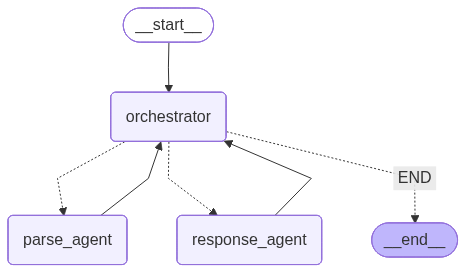

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

# **Test Cases**

We define a utility function to run the full graph on a single test query. It initializes an empty `UnifiedState`, invokes the compiled app (LangGraph workflow), and returns only the final answer.

In [ ]:
def test_case_execution(test_query):
    initial_state = {
        "user_query": test_query,
        "messages": [],

        # Parse Agent
        "parsed_output": "",
        "refined_output": "",
        "parse_route": "",

        # RAG Agent
        "case_chunks": "",
        "legal_chunks": "",
        "validation_status": "",
        "retrieval_attempt": 0,
        "seen_legal_ids": set(),

        # Orchestration
        "next_agent": "",

        # Final
        "final_output": ""
    }

    result = app.invoke(initial_state)

    return result["final_output"]

## Test Case 1: Rent Increase Notice Requirement

**Query**: If my rent is being increased by more than 5%, is the landlord expected to provide the advance written notice based on how long I've lived in the apartment?

In [ ]:
test_case = "If my rent is being increased by more than 5%, is the landlord expected to provide the advance written notice based on how long I've lived in the apartment?"
output = test_case_execution(test_case)
print(output)

In unregulated tenancies, if a landlord proposes to increase rent by more than 5%, they are required to provide advance written notice. The notice period is determined by the length of the tenant's occupancy:

- Tenants who have lived in the unit for twenty-four months or more, or whose lease term was twenty-four months or longer, must receive ninety-five days' notice.
- Tenants who have resided in the unit for more than thirteen months but fewer than twenty-four months are entitled to sixty-five days' notice.
- Tenancies of thirteen months or less require thirty-five days' advance notice.

Failure to provide the required notice may render the rent increase ineffective for the relevant period.

Supporting Case Reference: 
Carter v. Wilson - The court ruled that a rent increase exceeding 5% without the legally mandated notice was invalid, reinforcing the requirement for proper notice.


**Observation**

- The response correctly applies the statutory notice requirements based on tenancy duration and clearly concludes that failure to provide proper advance notice may invalidate the rent increase, with appropriate supporting case reference.


## Test Case 2: Unauthorized Entry Dispute

**Query**: My landlord entered my apartment without giving prior notice while I was at work. There was no emergency, and I did not provide consent. Does this violate my right to privacy, and what remedies are available to me?

In [ ]:
test_case = "My landlord entered my apartment without giving prior notice while I was at work. There was no emergency, and I did not provide consent. Does this violate my right to privacy, and what remedies are available to me?"
output = test_case_execution(test_case)
print(output)

Your landlord's entry into your apartment without prior notice and without your consent, in the absence of an emergency, does indeed violate your right to privacy as a tenant. According to the Residential Tenancy Rights, a landlord must provide at least twenty-five hours' advance written notice before entering a tenant's unit, except in genuine emergencies. Since there was no emergency in your case, this requirement was not met.

As for remedies available to you, you may consider the following options:

1. **File a Complaint**: You can file a complaint with your local housing authority or tenant's rights organization regarding the landlord's violation of your privacy rights.

2. **Seek Damages**: You may be entitled to seek damages for the violation of your privacy. This could include actual damages and potentially civil penalties.

3. **Retaliation Defense**: If you believe this action was taken in retaliation for exercising your tenant rights, you may raise a retaliation defense in c

**Observation**
- The response correctly explains that unauthorized, non-emergency entry without prior notice likely violates a tenant's right to privacy under law and outlines appropriate potential remedies.

- No supporting case is referenced because no relevant case from the archive applied to this scenario.


## Test Case 3: Out-of-Scope (Criminal) Query

**Query**: If someone steals my phone in a public place, what criminal charges apply and what punishment could they receive?

In [ ]:
test_case = "If someone steals my phone in a public place, what criminal charges apply and what punishment could they receive?"
output = test_case_execution(test_case)
print(output)

OUT_OF_SCOPE: This agent handles tenant-landlord (rental) law only. Please ask an in-scope question.


**Observation**

- The system correctly identifies the query as outside rental law and appropriately abstains from providing an answer, ensuring proper domain restriction.


## Test Case 4: Rent Regulation Status Clarification

**Query**: My landlord claims the apartment falls outside any rent regulation framework. What criteria determine whether a residential unit is subject to regulations?

In [ ]:
test_case = "My landlord claims the apartment falls outside any rent regulation framework. What criteria determine whether a residential unit is subject to regulations?"
output = test_case_execution(test_case)
print(output)

The determination of whether a residential unit is subject to rent regulation is based on specific criteria related to the building's age, size, location, and the history of the tenancy. There are two primary systems of rent regulation: primary-tier and secondary-tier.

1. **Primary-Tier Rent Regulation**: 
   - Applies to residential buildings constructed before January 1, 1968.
   - Must be located in municipalities that have recognized and not terminated a rental housing emergency.
   - To qualify as a protected tenant, the occupant or a lawful successor must have maintained continuous residency in the apartment since before July 1, 1983. Any gap in occupancy may result in the loss of this status.

2. **Secondary-Tier Rent Regulation**: 
   - Generally applies to buildings constructed before January 1, 1984, that contain eight or more residential units.
   - Apartments that were previously under primary-tier regulation and became vacant without a qualifying successor transition to s

**Observation**

- The response systematically explains the criteria used to determine whether a residential unit is subject to regulation, presenting the distinctions between primary-tier and secondary-tier systems in a structured and legally grounded manner.

- However, the cited case reference centers on the landlord’s burden in luxury deregulation disputes and documentation compliance, which does not directly address the foundational criteria used to determine whether a unit is subject to regulation in the first instance.

# **Limitations and Remedies**

While the system performs structured retrieval and controlled reasoning, certain limitations remain.

**Limitations**

- The final response is not independently validated for grounding accuracy beyond chunk-level relevance checks.

- The system cannot dynamically ask clarifying questions when critical legal details are missing.

- There is no Human-in-the-Loop (HITL) escalation for ambiguous or high-risk queries.

**Remedies**

- Introduce structured testing and answer-level grounding validation for improved reliability.

- Implement Human-in-the-Loop escalation for complex or sensitive cases.

___